# Introduction

This case study is part of the Google Data Analytics Professional Certification. The objective is to leverage a data set from a fictional company called Bellabeat to answer a series of key business questions. In order to answer the key business questions, I will follow the steps of the data analysis process: Ask, Prepare, Process, Analyze, Share, and Act.

## Bellabeat

Bellabeat is a high-tech manufacturer of health-focused products for women. Bellabeat is a successful small company, but they have the potential to become a larger player in the global smart device market. Urška Sršen, cofounder and Chief Creative Officer of Bellabeat, believes that analyzing smart device fitness data could help unlock new growth opportunities for the company.

# 1. Ask

## 1.1 Goal

The primary objective is to analyze smart device usage data from non-Bellabeat consumers (FitBit Fitness Tracker Data) to identify global trends in health and wellness tracking. By understanding how people interact with their smart devices, the goal is to apply these insights to a specific Bellabeat product and provide high-level, data-driven recommendations to improve the company’s marketing strategy and unlock new growth opportunities in the global market

## 1.2 Stakeholders

• Urška Sršen: Bellabeat’s cofounder and Chief Creative Officer; primary requester of the analysis.

• Sando Mur: Mathematician and Bellabeat’s cofounder; a key member of the executive team.

• Bellabeat Marketing Analytics Team: The team of data analysts responsible for guiding business goals through data.

## 1.3 Scope

Analyze smart device usage to gain insights into how consumers use non-FitBit smart devices to inform a new marketing strategy.

# 2. Prepare

## 2.1 Data Integrity

The data's quality is assessed using the ROCCC framework (Reliable, Original, Comprehensive, Current, and Cited). While useful for identifying habits, the dataset has limitations regarding sample size (only 30 users), potential bias, is not current (quite old), and the timeframe is at most 31 days for each user, with one user having data only for 4 days (not Comprehensive).

## 2.2 Privacy & Ethics

The data is de-identified and all users are assigned a randomized integer.

## 2.3 Storage

The original data is pulled from Kaggle. It will then be stored between two subfolders: /raw and /processed.

# 3. Process


## 3.1 Importing Libraries

The datasets will be pulled from Kaggle and stored locally using the kagglehub and shutil packages. This method will ensure that if the datasets are updated in the future, these datasets will pull the newest data. I am also using Polars package. Polars is a new, high-performance, open-source library for data manipulation and analysis. It offers significant performance gains for large datasets over libraries like Pandas because its core engine is written in Rust. While these datasets are not large by any means, the exposure to Polars is still warranted.

In [1]:
import kagglehub
import shutil
import polars as pl
import polars.selectors as cs
import os
import re
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\jacob\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3.2 Loading Datasets

The FitBit datasets are saved to a "raw_data" folder within the project folder. With the datasets downloaded and placed into the raw_data folder, three of the CSVs will be read in: dailyActivity_merged, sleepDay_merged, and weightLogInfo_merged.

In [2]:
dataset_identifier = "arashnic/fitbit"
download_path = "C:/Users/jacob/repositories/python/bellabeat_case_study/raw_data"
cache_path = kagglehub.dataset_download(dataset_identifier)
os.makedirs(download_path, exist_ok=True)
shutil.copytree(cache_path, download_path, dirs_exist_ok=True)

print("Path to dataset files:", download_path)

Path to dataset files: C:/Users/jacob/repositories/python/bellabeat_case_study/raw_data


In [3]:
first_files = os.listdir(download_path + '/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16')
second_files = os.listdir(download_path + "/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16")

print("Files found:", first_files)
print("Files found:", second_files)

Files found: ['dailyActivity_merged.csv', 'heartrate_seconds_merged.csv', 'hourlyCalories_merged.csv', 'hourlyIntensities_merged.csv', 'hourlySteps_merged.csv', 'minuteCaloriesNarrow_merged.csv', 'minuteIntensitiesNarrow_merged.csv', 'minuteMETsNarrow_merged.csv', 'minuteSleep_merged.csv', 'minuteStepsNarrow_merged.csv', 'weightLogInfo_merged.csv']
Files found: ['dailyActivity_merged.csv', 'dailyCalories_merged.csv', 'dailyIntensities_merged.csv', 'dailySteps_merged.csv', 'heartrate_seconds_merged.csv', 'hourlyCalories_merged.csv', 'hourlyIntensities_merged.csv', 'hourlySteps_merged.csv', 'minuteCaloriesNarrow_merged.csv', 'minuteCaloriesWide_merged.csv', 'minuteIntensitiesNarrow_merged.csv', 'minuteIntensitiesWide_merged.csv', 'minuteMETsNarrow_merged.csv', 'minuteSleep_merged.csv', 'minuteStepsNarrow_merged.csv', 'minuteStepsWide_merged.csv', 'sleepDay_merged.csv', 'weightLogInfo_merged.csv']


In [4]:
first_path = download_path + '/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16'
second_path = download_path + "/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16"

first_activity_file = os.path.join(first_path, 'dailyActivity_merged.csv')
second_activity_file = os.path.join(second_path, 'dailyActivity_merged.csv')
first_sleep_file = os.path.join(first_path, 'minuteSleep_merged.csv')
second_sleep_file = os.path.join(second_path, 'sleepDay_merged.csv')
first_weight_file = os.path.join(first_path, 'weightLogInfo_merged.csv')
second_weight_file = os.path.join(second_path, 'weightLogInfo_merged.csv')

activity_df = pl.concat([pl.read_csv(f, infer_schema_length=1000) for f in [first_activity_file, second_activity_file]])
first_sleep_df = pl.read_csv(first_sleep_file, infer_schema_length=1000)
second_sleep_df = pl.read_csv(second_sleep_file, infer_schema_length=1000)
weight_df = pl.concat([pl.read_csv(f, infer_schema_length=1000) for f in [first_weight_file, second_weight_file]])

In [5]:
print(activity_df.shape)
print(activity_df.head())
print(activity_df.schema)

(1397, 15)
shape: (5, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Id        ┆ ActivityD ┆ TotalStep ┆ TotalDist ┆ … ┆ FairlyAct ┆ LightlyAc ┆ Sedentary ┆ Calories │
│ ---       ┆ ate       ┆ s         ┆ ance      ┆   ┆ iveMinute ┆ tiveMinut ┆ Minutes   ┆ ---      │
│ i64       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ s         ┆ es        ┆ ---       ┆ i64      │
│           ┆ str       ┆ i64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ i64       ┆          │
│           ┆           ┆           ┆           ┆   ┆ i64       ┆ i64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 150396036 ┆ 3/25/2016 ┆ 11004     ┆ 7.11      ┆ … ┆ 12        ┆ 205       ┆ 804       ┆ 1819     │
│ 6         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ 150396036 ┆ 3/26/2016 ┆ 17609     ┆ 11.55     ┆ … ┆ 17        ┆

In [6]:
print(first_sleep_df.shape)
print(first_sleep_df.head())
print(first_sleep_df.schema)

(198559, 4)
shape: (5, 4)
┌────────────┬──────────────────────┬───────┬─────────────┐
│ Id         ┆ date                 ┆ value ┆ logId       │
│ ---        ┆ ---                  ┆ ---   ┆ ---         │
│ i64        ┆ str                  ┆ i64   ┆ i64         │
╞════════════╪══════════════════════╪═══════╪═════════════╡
│ 1503960366 ┆ 3/13/2016 2:39:30 AM ┆ 1     ┆ 11114919637 │
│ 1503960366 ┆ 3/13/2016 2:40:30 AM ┆ 1     ┆ 11114919637 │
│ 1503960366 ┆ 3/13/2016 2:41:30 AM ┆ 1     ┆ 11114919637 │
│ 1503960366 ┆ 3/13/2016 2:42:30 AM ┆ 1     ┆ 11114919637 │
│ 1503960366 ┆ 3/13/2016 2:43:30 AM ┆ 1     ┆ 11114919637 │
└────────────┴──────────────────────┴───────┴─────────────┘
Schema({'Id': Int64, 'date': String, 'value': Int64, 'logId': Int64})


In [7]:
print(second_sleep_df.shape)
print(second_sleep_df.head())
print(second_sleep_df.schema)

(413, 5)
shape: (5, 5)
┌────────────┬───────────────────────┬───────────────────┬────────────────────┬────────────────┐
│ Id         ┆ SleepDay              ┆ TotalSleepRecords ┆ TotalMinutesAsleep ┆ TotalTimeInBed │
│ ---        ┆ ---                   ┆ ---               ┆ ---                ┆ ---            │
│ i64        ┆ str                   ┆ i64               ┆ i64                ┆ i64            │
╞════════════╪═══════════════════════╪═══════════════════╪════════════════════╪════════════════╡
│ 1503960366 ┆ 4/12/2016 12:00:00 AM ┆ 1                 ┆ 327                ┆ 346            │
│ 1503960366 ┆ 4/13/2016 12:00:00 AM ┆ 2                 ┆ 384                ┆ 407            │
│ 1503960366 ┆ 4/15/2016 12:00:00 AM ┆ 1                 ┆ 412                ┆ 442            │
│ 1503960366 ┆ 4/16/2016 12:00:00 AM ┆ 2                 ┆ 340                ┆ 367            │
│ 1503960366 ┆ 4/17/2016 12:00:00 AM ┆ 1                 ┆ 700                ┆ 712            │
└──────

In [8]:
print(weight_df.shape)
print(weight_df.head())
print(weight_df.schema)

(100, 8)
shape: (5, 8)
┌────────────┬─────────────┬────────────┬─────────────┬──────┬───────────┬────────────┬────────────┐
│ Id         ┆ Date        ┆ WeightKg   ┆ WeightPound ┆ Fat  ┆ BMI       ┆ IsManualRe ┆ LogId      │
│ ---        ┆ ---         ┆ ---        ┆ s           ┆ ---  ┆ ---       ┆ port       ┆ ---        │
│ i64        ┆ str         ┆ f64        ┆ ---         ┆ i64  ┆ f64       ┆ ---        ┆ i64        │
│            ┆             ┆            ┆ f64         ┆      ┆           ┆ bool       ┆            │
╞════════════╪═════════════╪════════════╪═════════════╪══════╪═══════════╪════════════╪════════════╡
│ 1503960366 ┆ 4/5/2016    ┆ 53.299999  ┆ 117.506384  ┆ 22   ┆ 22.969999 ┆ true       ┆ 1459900799 │
│            ┆ 11:59:59 PM ┆            ┆             ┆      ┆           ┆            ┆ 000        │
│ 1927972279 ┆ 4/10/2016   ┆ 129.600006 ┆ 285.719105  ┆ null ┆ 46.169998 ┆ false      ┆ 1460313206 │
│            ┆ 6:33:26 PM  ┆            ┆             ┆      ┆      

## 3.3 Data Cleaning

This next section will be to clean the datasets to prepare them for analysis.

### 3.3.1 Transform First Sleep Dataset

The sleep datasets have different schemas, so we need to modify the datasets so we can combine them for analysis. The first sleep dataset is by the minute, so we will need to convert the date column from a string to a datetime, truncate it to the day level, and then perform a group-by aggregation.

In [9]:
first_sleep_daily = (
    first_sleep_df.with_columns(
        pl.col("date").str.to_datetime("%m/%d/%Y %I:%M:%S %p")
    )
    .group_by(['Id', pl.col("date").dt.date()])
    .agg(
        pl.col('value').sum().alias('TotalMinutesAsleep')
    )
    .sort(['Id', 'date'])
)

print(first_sleep_daily.shape)
print(first_sleep_daily.head())
print(first_sleep_daily.schema)

(467, 3)
shape: (5, 3)
┌────────────┬────────────┬────────────────────┐
│ Id         ┆ date       ┆ TotalMinutesAsleep │
│ ---        ┆ ---        ┆ ---                │
│ i64        ┆ date       ┆ i64                │
╞════════════╪════════════╪════════════════════╡
│ 1503960366 ┆ 2016-03-13 ┆ 441                │
│ 1503960366 ┆ 2016-03-14 ┆ 423                │
│ 1503960366 ┆ 2016-03-15 ┆ 365                │
│ 1503960366 ┆ 2016-03-16 ┆ 404                │
│ 1503960366 ┆ 2016-03-17 ┆ 473                │
└────────────┴────────────┴────────────────────┘
Schema({'Id': Int64, 'date': Date, 'TotalMinutesAsleep': Int64})


### 3.3.2 Column Names

We saw earlier that the column names are in PascalCase, so to keep with industry standards we will convert them to snake_case. Since the column names are in PascalCase, it will take using Regex to get all the column names into snake_case.

In [10]:
def to_snake_case (name: str) -> str:
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    s2 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()
    return s2.replace(" ", "_").replace("-","_")

In [11]:
activity_df, first_sleep_df, second_sleep_df, weight_df = [df.rename(to_snake_case) for df in [activity_df, first_sleep_daily, second_sleep_df, weight_df]]

print(activity_df.schema)
print(first_sleep_df.schema)
print(second_sleep_df.schema)
print(weight_df.schema)

Schema({'id': Int64, 'activity_date': String, 'total_steps': Int64, 'total_distance': Float64, 'tracker_distance': Float64, 'logged_activities_distance': Float64, 'very_active_distance': Float64, 'moderately_active_distance': Float64, 'light_active_distance': Float64, 'sedentary_active_distance': Float64, 'very_active_minutes': Int64, 'fairly_active_minutes': Int64, 'lightly_active_minutes': Int64, 'sedentary_minutes': Int64, 'calories': Int64})
Schema({'id': Int64, 'date': Date, 'total_minutes_asleep': Int64})
Schema({'id': Int64, 'sleep_day': String, 'total_sleep_records': Int64, 'total_minutes_asleep': Int64, 'total_time_in_bed': Int64})
Schema({'id': Int64, 'date': String, 'weight_kg': Float64, 'weight_pounds': Float64, 'fat': Int64, 'bmi': Float64, 'is_manual_report': Boolean, 'log_id': Int64})


### 3.3.2 Date Column

With the column names handled, we realize that the three datasets all use a different name for their date columns and they are strings. So we will make all three datasets have the same name for their 'date' column and convert them from string to dates.

In [12]:
activity_df = activity_df.rename({'activity_date': 'date'})
second_sleep_df = second_sleep_df.rename({'sleep_day': 'date'})

activity_df = activity_df.with_columns(pl.col("date").str.to_date("%m/%d/%Y"))
second_sleep_df = second_sleep_df.with_columns(pl.col("date").str.split(" ").list.get(0).str.to_date("%m/%d/%Y"))
weight_df = weight_df.with_columns(pl.col("date").str.split(" ").list.get(0).str.to_date("%m/%d/%Y"))

print(activity_df.head())
print(second_sleep_df.head())
print(weight_df.head())

shape: (5, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ date      ┆ total_ste ┆ total_dis ┆ … ┆ fairly_ac ┆ lightly_a ┆ sedentary ┆ calories │
│ ---       ┆ ---       ┆ ps        ┆ tance     ┆   ┆ tive_minu ┆ ctive_min ┆ _minutes  ┆ ---      │
│ i64       ┆ date      ┆ ---       ┆ ---       ┆   ┆ tes       ┆ utes      ┆ ---       ┆ i64      │
│           ┆           ┆ i64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ i64       ┆          │
│           ┆           ┆           ┆           ┆   ┆ i64       ┆ i64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 150396036 ┆ 2016-03-2 ┆ 11004     ┆ 7.11      ┆ … ┆ 12        ┆ 205       ┆ 804       ┆ 1819     │
│ 6         ┆ 5         ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ 150396036 ┆ 2016-03-2 ┆ 17609     ┆ 11.55     ┆ … ┆ 17        ┆ 274       

### 3.3.3 Merge Sleep Datasets

The two sleep datasets are now ready to be combined. We will drop two of the columns from the second sleep dataset that we will not be using so we can then concatenate the two datasets.

In [13]:
second_sleep_df = second_sleep_df.drop(['total_sleep_records', 'total_time_in_bed'])
sleep_df = pl.concat([first_sleep_df, second_sleep_df])

print(sleep_df.shape)

(880, 3)


### 3.3.4 Missing Data

Next, we check for missing values. The only dataset that is missing values is the weight_df. In this case, however, we cannot simply drop the rows with missing data because the missing data is all from a single column, 'fat', and it is missing data for 96 out of 100 rows. With only four rows having data for this column, we will just drop the column as a whole.

In [14]:
print(activity_df.null_count(), sleep_df.null_count(), weight_df.null_count())

shape: (1, 15)
┌─────┬──────┬─────────────┬──────────────┬───┬─────────────┬─────────────┬─────────────┬──────────┐
│ id  ┆ date ┆ total_steps ┆ total_distan ┆ … ┆ fairly_acti ┆ lightly_act ┆ sedentary_m ┆ calories │
│ --- ┆ ---  ┆ ---         ┆ ce           ┆   ┆ ve_minutes  ┆ ive_minutes ┆ inutes      ┆ ---      │
│ u32 ┆ u32  ┆ u32         ┆ ---          ┆   ┆ ---         ┆ ---         ┆ ---         ┆ u32      │
│     ┆      ┆             ┆ u32          ┆   ┆ u32         ┆ u32         ┆ u32         ┆          │
╞═════╪══════╪═════════════╪══════════════╪═══╪═════════════╪═════════════╪═════════════╪══════════╡
│ 0   ┆ 0    ┆ 0           ┆ 0            ┆ … ┆ 0           ┆ 0           ┆ 0           ┆ 0        │
└─────┴──────┴─────────────┴──────────────┴───┴─────────────┴─────────────┴─────────────┴──────────┘ shape: (1, 3)
┌─────┬──────┬──────────────────────┐
│ id  ┆ date ┆ total_minutes_asleep │
│ --- ┆ ---  ┆ ---                  │
│ u32 ┆ u32  ┆ u32                  │
╞═════╪════

In [15]:
weight_df = weight_df.drop("fat")
print(weight_df.head())

shape: (5, 7)
┌────────────┬────────────┬────────────┬───────────────┬───────────┬───────────────┬───────────────┐
│ id         ┆ date       ┆ weight_kg  ┆ weight_pounds ┆ bmi       ┆ is_manual_rep ┆ log_id        │
│ ---        ┆ ---        ┆ ---        ┆ ---           ┆ ---       ┆ ort           ┆ ---           │
│ i64        ┆ date       ┆ f64        ┆ f64           ┆ f64       ┆ ---           ┆ i64           │
│            ┆            ┆            ┆               ┆           ┆ bool          ┆               │
╞════════════╪════════════╪════════════╪═══════════════╪═══════════╪═══════════════╪═══════════════╡
│ 1503960366 ┆ 2016-04-05 ┆ 53.299999  ┆ 117.506384    ┆ 22.969999 ┆ true          ┆ 1459900799000 │
│ 1927972279 ┆ 2016-04-10 ┆ 129.600006 ┆ 285.719105    ┆ 46.169998 ┆ false         ┆ 1460313206000 │
│ 2347167796 ┆ 2016-04-03 ┆ 63.400002  ┆ 139.773078    ┆ 24.77     ┆ true          ┆ 1459727999000 │
│ 2873212765 ┆ 2016-04-06 ┆ 56.700001  ┆ 125.002104    ┆ 21.450001 ┆ true    

### 3.3.5 Duplicate Data

Lastly, we check for any duplicated data. We are only concerned with rows that are complete duplicates (i.e. two or more rows that are identical across all columns). We find the sleep_df and weight_df have duplicate rows.

In [16]:
print(activity_df.filter(activity_df.is_duplicated()), sleep_df.filter(sleep_df.is_duplicated()), weight_df.filter(weight_df.is_duplicated()))

shape: (0, 15)
┌─────┬──────┬─────────────┬──────────────┬───┬─────────────┬─────────────┬─────────────┬──────────┐
│ id  ┆ date ┆ total_steps ┆ total_distan ┆ … ┆ fairly_acti ┆ lightly_act ┆ sedentary_m ┆ calories │
│ --- ┆ ---  ┆ ---         ┆ ce           ┆   ┆ ve_minutes  ┆ ive_minutes ┆ inutes      ┆ ---      │
│ i64 ┆ date ┆ i64         ┆ ---          ┆   ┆ ---         ┆ ---         ┆ ---         ┆ i64      │
│     ┆      ┆             ┆ f64          ┆   ┆ i64         ┆ i64         ┆ i64         ┆          │
╞═════╪══════╪═════════════╪══════════════╪═══╪═════════════╪═════════════╪═════════════╪══════════╡
└─────┴──────┴─────────────┴──────────────┴───┴─────────────┴─────────────┴─────────────┴──────────┘ shape: (6, 3)
┌────────────┬────────────┬──────────────────────┐
│ id         ┆ date       ┆ total_minutes_asleep │
│ ---        ┆ ---        ┆ ---                  │
│ i64        ┆ date       ┆ i64                  │
╞════════════╪════════════╪══════════════════════╡
│ 4388161

In [17]:
sleep_df = sleep_df.unique()
weight_df = weight_df.unique()

print(sleep_df.filter(sleep_df.is_duplicated()))
print(weight_df.filter(weight_df.is_duplicated()))

shape: (0, 3)
┌─────┬──────┬──────────────────────┐
│ id  ┆ date ┆ total_minutes_asleep │
│ --- ┆ ---  ┆ ---                  │
│ i64 ┆ date ┆ i64                  │
╞═════╪══════╪══════════════════════╡
└─────┴──────┴──────────────────────┘
shape: (0, 7)
┌─────┬──────┬───────────┬───────────────┬─────┬──────────────────┬────────┐
│ id  ┆ date ┆ weight_kg ┆ weight_pounds ┆ bmi ┆ is_manual_report ┆ log_id │
│ --- ┆ ---  ┆ ---       ┆ ---           ┆ --- ┆ ---              ┆ ---    │
│ i64 ┆ date ┆ f64       ┆ f64           ┆ f64 ┆ bool             ┆ i64    │
╞═════╪══════╪═══════════╪═══════════════╪═════╪══════════════════╪════════╡
└─────┴──────┴───────────┴───────────────┴─────┴──────────────────┴────────┘


### 3.3.5 Export Cleaned Data

With the datasets cleaned, we export the datasets to a clean_data folder to keep them separate from the raw_data.

In [18]:
clean_data_path = "C:/Users/jacob/repositories/python/bellabeat_case_study/clean_data"
os.makedirs(clean_data_path, exist_ok=True)

activity_df.write_csv(clean_data_path + "/daily_activity_clean.csv")
sleep_df.write_csv(clean_data_path + "/daily_sleep_clean.csv")
weight_df.write_csv(clean_data_path + "/weight_log_clean.csv")

# 4. Analyze

## 4.1 Load Cleaned Data

With the data processed, cleaned, and exported, we can read in the cleaned data for analysis.

In [19]:
daily_activity_clean_df = pl.read_csv(clean_data_path + "/daily_activity_clean.csv").with_columns(pl.col('date').str.to_date("%Y-%m-%d"))
sleep_clean_df = pl.read_csv(clean_data_path + "/daily_sleep_clean.csv").with_columns(pl.col('date').str.to_date("%Y-%m-%d"))
weight_clean_df = pl.read_csv(clean_data_path + "/weight_log_clean.csv").with_columns(pl.col('date').str.to_date("%Y-%m-%d"))

## 4.2 Exploratory Data Analysis

With the cleaned data, we will first look at the summary statistics for each dataset. These metrics include mean, maximum, minimum, and the percentiles.

In [20]:
daily_activity_clean_df.describe()

statistic,id,date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1397.0,"""1397""",1397.0,1397.0,1397.0,1397.0,1397.0,1397.0,1397.0,1397.0,1397.0,1397.0,1397.0,1397.0,1397.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",4.7812e9,"""2016-04-19 01:26:35.132426""",7280.898354,5.219434,5.192219,0.131481,1.397416,0.538461,3.193407,0.001704,19.679313,13.403006,185.372942,992.542591,2266.265569
"""std""",2.3843e9,null,5214.336113,3.994206,3.980077,0.703683,2.60748,0.867436,2.116869,0.007736,31.675878,26.401247,114.058601,313.297376,753.005527
"""min""",1.5040e9,"""2016-03-12""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",2.3201e9,"""2016-04-09""",3146.0,2.17,2.16,0.0,0.0,0.0,1.61,0.0,0.0,0.0,111.0,729.0,1799.0
"""50%""",4.4451e9,"""2016-04-19""",6999.0,4.95,4.95,0.0,0.1,0.2,3.24,0.0,2.0,6.0,195.0,1057.0,2114.0
"""75%""",6.9622e9,"""2016-04-30""",10544.0,7.5,7.48,0.0,1.83,0.77,4.69,0.0,30.0,18.0,262.0,1244.0,2770.0
"""max""",8.8777e9,"""2016-05-12""",36019.0,28.030001,28.030001,6.727057,21.92,6.48,12.51,0.11,210.0,660.0,720.0,1440.0,4900.0


In [21]:
sleep_clean_df.describe()

statistic,id,date,total_minutes_asleep
str,f64,str,f64
"""count""",877.0,"""877""",877.0
"""null_count""",0.0,"""0""",0.0
"""mean""",4.9102e9,"""2016-04-10 06:22:34.618015""",441.81984
"""std""",2.1169e9,null,157.620062
"""min""",1.5040e9,"""2016-03-11""",6.0
"""25%""",3.9773e9,"""2016-03-27""",379.0
"""50%""",4.7029e9,"""2016-04-10""",454.0
"""75%""",6.7759e9,"""2016-04-26""",526.0
"""max""",8.7920e9,"""2016-05-12""",1201.0


In [22]:
weight_clean_df.describe()

statistic,id,date,weight_kg,weight_pounds,bmi,is_manual_report,log_id
str,f64,str,f64,f64,f64,f64,f64
"""count""",98.0,"""98""",98.0,98.0,98.0,98.0,98.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",6.8115e9,"""2016-04-20 03:25:42.857143""",72.466327,159.760904,25.372041,0.642857,1.4612e12
"""std""",2.0899e9,null,14.820618,32.67387,3.555762,null,1.0895e9
"""min""",1.5040e9,"""2016-03-30""",52.599998,115.963147,21.450001,0.0,1.4594e12
"""25%""",6.9622e9,"""2016-04-08""",61.5,135.584291,24.0,null,1.4602e12
"""50%""",6.9622e9,"""2016-04-20""",62.5,137.788914,24.389999,null,1.4611e12
"""75%""",8.8777e9,"""2016-05-01""",85.300003,188.054316,25.59,null,1.4621e12
"""max""",8.8777e9,"""2016-05-12""",133.5,294.31712,47.540001,1.0,1.4631e12


## 4.3 Correlation

We want to look at the correlations between the daily activity levels and sleep. So we will join the sleep data to the activity data and create a correlation matrix.

In [23]:
joined_df = daily_activity_clean_df.join(sleep_clean_df, how='inner', on=['id', 'date'])
joined_df.shape

(628, 16)

In [24]:
correlation_matrix = joined_df.drop('id').corr(label='cols')

long_corr = correlation_matrix.unpivot(
    index='cols',
    on = None,
    variable_name='variable_2',
    value_name='correlation'
)

extreme_correlations = (
    long_corr
    .filter(
        ((pl.col('correlation') > 0.7) |
        (pl.col('correlation') < 0.3)) &
        (pl.col('cols') != pl.col('variable_2'))
    )
    .sort('correlation', descending=True)
)

With the correlation matrix built, we will look at three variables in particular: total_steps, calories, and total_minutes_asleep.

In [25]:
with pl.Config(tbl_rows=-1):
    print(extreme_correlations.filter(pl.col('cols') == 'total_steps'))

shape: (7, 3)
┌─────────────┬────────────────────────────┬─────────────┐
│ cols        ┆ variable_2                 ┆ correlation │
│ ---         ┆ ---                        ┆ ---         │
│ str         ┆ str                        ┆ f64         │
╞═════════════╪════════════════════════════╪═════════════╡
│ total_steps ┆ total_distance             ┆ 0.984637    │
│ total_steps ┆ tracker_distance           ┆ 0.98459     │
│ total_steps ┆ logged_activities_distance ┆ 0.142754    │
│ total_steps ┆ date                       ┆ 0.070961    │
│ total_steps ┆ sedentary_active_distance  ┆ 0.05835     │
│ total_steps ┆ sedentary_minutes          ┆ -0.044181   │
│ total_steps ┆ total_minutes_asleep       ┆ -0.171828   │
└─────────────┴────────────────────────────┴─────────────┘


In [26]:
with pl.Config(tbl_rows=-1):
    print(extreme_correlations.filter(pl.col('cols') == 'calories'))

shape: (8, 3)
┌──────────┬────────────────────────────┬─────────────┐
│ cols     ┆ variable_2                 ┆ correlation │
│ ---      ┆ ---                        ┆ ---         │
│ str      ┆ str                        ┆ f64         │
╞══════════╪════════════════════════════╪═════════════╡
│ calories ┆ logged_activities_distance ┆ 0.244648    │
│ calories ┆ lightly_active_minutes     ┆ 0.235787    │
│ calories ┆ fairly_active_minutes      ┆ 0.218786    │
│ calories ┆ sedentary_minutes          ┆ 0.194414    │
│ calories ┆ moderately_active_distance ┆ 0.107878    │
│ calories ┆ sedentary_active_distance  ┆ 0.046355    │
│ calories ┆ date                       ┆ -0.000442   │
│ calories ┆ total_minutes_asleep       ┆ -0.087206   │
└──────────┴────────────────────────────┴─────────────┘


In [27]:
with pl.Config(tbl_rows=-1):
    print(extreme_correlations.filter(pl.col('cols') == 'total_minutes_asleep'))

shape: (14, 3)
┌──────────────────────┬────────────────────────────┬─────────────┐
│ cols                 ┆ variable_2                 ┆ correlation │
│ ---                  ┆ ---                        ┆ ---         │
│ str                  ┆ str                        ┆ f64         │
╞══════════════════════╪════════════════════════════╪═════════════╡
│ total_minutes_asleep ┆ lightly_active_minutes     ┆ -0.008749   │
│ total_minutes_asleep ┆ sedentary_active_distance  ┆ -0.03968    │
│ total_minutes_asleep ┆ light_active_distance      ┆ -0.066442   │
│ total_minutes_asleep ┆ calories                   ┆ -0.087206   │
│ total_minutes_asleep ┆ logged_activities_distance ┆ -0.109358   │
│ total_minutes_asleep ┆ very_active_minutes        ┆ -0.125422   │
│ total_minutes_asleep ┆ very_active_distance       ┆ -0.135862   │
│ total_minutes_asleep ┆ moderately_active_distance ┆ -0.141415   │
│ total_minutes_asleep ┆ date                       ┆ -0.141621   │
│ total_minutes_asleep ┆ fairly_a

Of the three variables we looked at, total_minutes_asleep looks to have some signal. From here, we can build an ML model.

## 4.4 Model Building

We will look at how well the total_steps, total_minutes_asleep, and sedentary_minutes_percentage can cluster the users. We will use K-Means Clustering, and will create a sedentary_minutes_percentage variable to help normalize the data. We also filter out any entries with a total_minutes_tracked less than 1000 minutes. There are 1440 minutes in a 24-hour period, so any user with less than 1000 tracked minutes are likely not wearing their watch.

In [28]:
sleep_columns = [
    'very_active_minutes',
    'fairly_active_minutes',
    'lightly_active_minutes',
    'sedentary_minutes',
]

joined_df = joined_df.with_columns(
    pl.sum_horizontal(sleep_columns).alias('total_minutes_tracked')
).with_columns(
    (pl.col('sedentary_minutes') / pl.col('total_minutes_tracked') * 100).round(2)
    .fill_nan(0)
    .alias('sedentary_minutes_percentage')
).filter(
    pl.col('total_minutes_tracked') >= 1000
)

print(joined_df.shape)
print(joined_df.head())

(264, 18)
shape: (5, 18)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ id        ┆ date      ┆ total_ste ┆ total_dis ┆ … ┆ calories ┆ total_min ┆ total_min ┆ sedentary │
│ ---       ┆ ---       ┆ ps        ┆ tance     ┆   ┆ ---      ┆ utes_asle ┆ utes_trac ┆ _minutes_ │
│ i64       ┆ date      ┆ ---       ┆ ---       ┆   ┆ i64      ┆ ep        ┆ ked       ┆ percentag │
│           ┆           ┆ i64       ┆ f64       ┆   ┆          ┆ ---       ┆ ---       ┆ e         │
│           ┆           ┆           ┆           ┆   ┆          ┆ i64       ┆ i64       ┆ ---       │
│           ┆           ┆           ┆           ┆   ┆          ┆           ┆           ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ 150396036 ┆ 2016-03-2 ┆ 11004     ┆ 7.11      ┆ … ┆ 1819     ┆ 424       ┆ 1054      ┆ 76.28     │
│ 6         ┆ 5         ┆           ┆           ┆   ┆          ┆  

In [29]:
weekly_steps = (
    joined_df
    .with_columns(
        pl.col('date').dt.truncate('1w').alias('week')
    )
    .group_by(['id','week'])
    .agg([
        pl.col('total_steps').mean().round(2).alias('average_steps_per_week'),
        pl.col('total_minutes_asleep').mean().round(2).alias('average_sleep_duration'),
        pl.col('sedentary_minutes_percentage').mean().round(2).alias('weekly_sedentary_percentage'),
        pl.col('date').n_unique().alias('days_tracked')
    ])
    .sort(['id','week'])
)

print(weekly_steps.shape)
print(weekly_steps.head())

(112, 6)
shape: (5, 6)
┌────────────┬────────────┬───────────────────┬──────────────────┬──────────────────┬──────────────┐
│ id         ┆ week       ┆ average_steps_per ┆ average_sleep_du ┆ weekly_sedentary ┆ days_tracked │
│ ---        ┆ ---        ┆ _week             ┆ ration           ┆ _percentage      ┆ ---          │
│ i64        ┆ date       ┆ ---               ┆ ---              ┆ ---              ┆ u32          │
│            ┆            ┆ f64               ┆ f64              ┆ f64              ┆              │
╞════════════╪════════════╪═══════════════════╪══════════════════╪══════════════════╪══════════════╡
│ 1503960366 ┆ 2016-03-21 ┆ 11004.0           ┆ 424.0            ┆ 76.28            ┆ 1            │
│ 1503960366 ┆ 2016-03-28 ┆ 11961.2           ┆ 334.0            ┆ 73.27            ┆ 5            │
│ 1503960366 ┆ 2016-04-04 ┆ 13944.33          ┆ 390.67           ┆ 68.38            ┆ 3            │
│ 1503960366 ┆ 2016-04-11 ┆ 11889.0           ┆ 350.5            ┆ 7

With our dataset ready to go, we can start building the KMeans model. For sklearn, we have to convert our dataset to a Pandas dataframe.

In [30]:
kmeans_features = weekly_steps.select(pl.all().exclude(['id','week', 'days_tracked'])).to_pandas()

In [31]:
kmeans_features.corr()

,average_steps_per_week,average_sleep_duration,weekly_sedentary_percentage
average_steps_per_week,1.000000,0.041922,-0.740612
average_sleep_duration,0.041922,1.000000,-0.291553
weekly_sedentary_percentage,-0.740612,-0.291553,1.000000


The correlation matrix shows a strong negative correlation between the weekly_sedentary_percentage and average_steps_per_week, which we would expect.

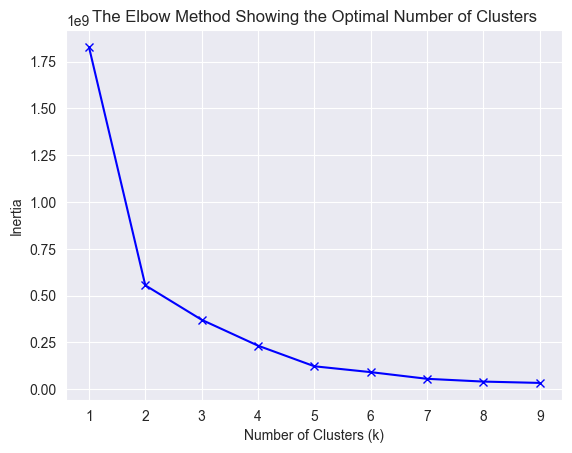

In [32]:
inertia = []
K = range(1, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=49)
    km.fit(kmeans_features)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method Showing the Optimal Number of Clusters')
plt.show()

The chart shows that our optimal number of clusters is two.

In [33]:
kmeans = KMeans(n_clusters=2, random_state=49)
clusters = kmeans.fit_predict(kmeans_features)
weekly_steps = weekly_steps.with_columns(
    pl.Series(name="user_segment", values=clusters)
)

print(weekly_steps.head())

shape: (5, 7)
┌────────────┬────────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┐
│ id         ┆ week       ┆ average_step ┆ average_slee ┆ weekly_seden ┆ days_tracke ┆ user_segmen │
│ ---        ┆ ---        ┆ s_per_week   ┆ p_duration   ┆ tary_percent ┆ d           ┆ t           │
│ i64        ┆ date       ┆ ---          ┆ ---          ┆ age          ┆ ---         ┆ ---         │
│            ┆            ┆ f64          ┆ f64          ┆ ---          ┆ u32         ┆ i32         │
│            ┆            ┆              ┆              ┆ f64          ┆             ┆             │
╞════════════╪════════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╡
│ 1503960366 ┆ 2016-03-21 ┆ 11004.0      ┆ 424.0        ┆ 76.28        ┆ 1           ┆ 1           │
│ 1503960366 ┆ 2016-03-28 ┆ 11961.2      ┆ 334.0        ┆ 73.27        ┆ 5           ┆ 1           │
│ 1503960366 ┆ 2016-04-04 ┆ 13944.33     ┆ 390.67       ┆ 68.38        ┆ 3   

In [34]:
score = silhouette_score(kmeans_features, clusters)

print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.627


With two clusters, we get a silhouette score of 0.627.

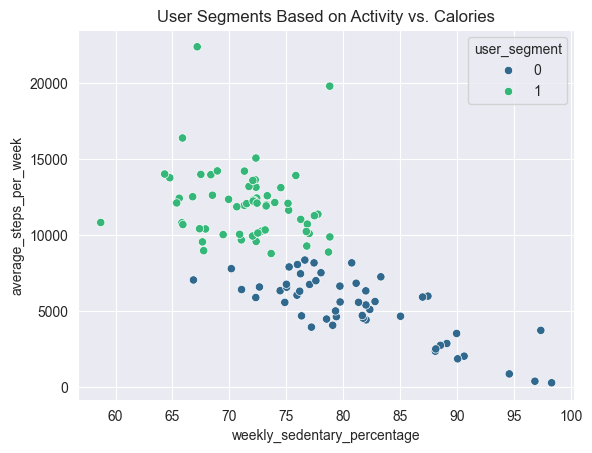

In [35]:
scatter_df = weekly_steps.to_pandas()

sns.scatterplot(
    data = scatter_df,
    x = 'weekly_sedentary_percentage',
    y = 'average_steps_per_week',
    hue = 'user_segment',
    palette = 'viridis'
)

plt.title('User Segments Based on Activity vs. Calories')
plt.show()

We do see something interesting here, we have users that have a sedentary percentage greater than or equal to 90%. Since we already filtered out users with less than 1000 tracked minutes in a day, this means either the users really are sedentary for 21.6+ hours, or they were possibly sick or injured.

# 5. Recommendations

The data has identified a group of "super sedentary" users, those users whose total minutes tracked is close to 1440 minutes, but they are spending +90% of their day in a sitting or laying down position. This group is a prime target for some sort of 'inactivity alert'. The marketing strategy can include a "move of the hour" nudge for this segment of users.